# DataLoaders Setup

In [ ]:
!gdown 1EplRWNK92eE4ksjq9bw9kR4rzXLy-Xlk

Downloading...
From (original): https://drive.google.com/uc?id=1EplRWNK92eE4ksjq9bw9kR4rzXLy-Xlk
From (redirected): https://drive.google.com/uc?id=1EplRWNK92eE4ksjq9bw9kR4rzXLy-Xlk&confirm=t&uuid=35049a3e-584d-4b1a-84ad-b19e8d2060ee
To: /content/dataset_kidney.zip
100% 711M/711M [00:03<00:00, 199MB/s]


In [ ]:
!unzip /content/dataset_kidney.zip

Archive:  /content/dataset_kidney.zip
   creating: content/drive/MyDrive/kidney_stone_detection/
   creating: content/drive/MyDrive/kidney_stone_detection/Normal/
  inflating: content/drive/MyDrive/kidney_stone_detection/Normal/1.3.46.670589.33.1.63717267565321350500001.5048058584640271356.png  
  inflating: content/drive/MyDrive/kidney_stone_detection/Normal/1.3.46.670589.33.1.63715729986989004400001.4920074281278180338.png  
  inflating: content/drive/MyDrive/kidney_stone_detection/Normal/1.3.46.670589.33.1.63717100710073776200001.4962450969032728502.png  
  inflating: content/drive/MyDrive/kidney_stone_detection/Normal/1.3.46.670589.33.1.63717622618894617100001.4963681960294693890.png  
  inflating: content/drive/MyDrive/kidney_stone_detection/Normal/1.3.46.670589.33.1.63717100709963770000001.5160724910887398844.png  
  inflating: content/drive/MyDrive/kidney_stone_detection/Normal/1.3.46.670589.33.1.63719435405513517000001.4675294517967595390.png  
  inflating: content/drive/MyDriv

 # Import Libraries

In [ ]:
!pip install tensorflow

In [ ]:
import os, random, hashlib, collections, itertools, warnings, math, gc, functools
from pathlib import Path
import numpy as np
import pandas as pd
import pathlib, time
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

#EDA

In [ ]:
plt.rcParams['figure.figsize'] = (6, 4)

ROOT = Path('/content/content/drive/MyDrive/kidney_stone_detection')
STONE_DIR  = ROOT/'Kidney_stone'
NORMAL_DIR = ROOT/'Normal'

## Image counts

In [ ]:
def list_imgs(folder, exts={'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}):
    return [p for p in folder.rglob('*') if p.suffix.lower() in exts]

stone_files  = list_imgs(STONE_DIR)
normal_files = list_imgs(NORMAL_DIR)

print(f'Kidney stone images : {len(stone_files):,}')
print(f'Normal images       : {len(normal_files):,}')
print(f'Total images        : {len(stone_files)+len(normal_files):,}')

Kidney stone images : 781
Normal images       : 1,009
Total images        : 1,790


## Scan each image for shape, mode & corruption



In [ ]:
records = []
bad_files = []

for label, paths in (('stone', stone_files), ('normal', normal_files)):
    for p in paths:
        try:
            with Image.open(p) as im:
                w, h   = im.size
                mode   = im.mode
                record = dict(path=str(p), label=label,
                              width=w, height=h, mode=mode,
                              channels = len(im.getbands()))
                records.append(record)
        except (UnidentifiedImageError, OSError) as e:
            bad_files.append(str(p))

df = pd.DataFrame(records)
print(f'Loaded {len(df):,} images; Corrupted {len(bad_files)}')
df.head()

Loaded 1,790 images; Corrupted 0


,path,label,width,height,mode,channels
0,/content/content/drive/MyDrive/kidney_stone_de...,stone,1078,1160,L,1
1,/content/content/drive/MyDrive/kidney_stone_de...,stone,956,1204,L,1
2,/content/content/drive/MyDrive/kidney_stone_de...,stone,940,1306,L,1
3,/content/content/drive/MyDrive/kidney_stone_de...,stone,956,1336,L,1
4,/content/content/drive/MyDrive/kidney_stone_de...,stone,1010,1240,L,1


- The mode  describes the color format and pixel depth of the image.
- Mode L means 8-bit pixels, black and white (grayscale) with channel 1.
- corruption means image is corrupted or not
-  from shape it shows that each image has different width and heights

##Channel depth check (RGB vs grayscale)

In [ ]:
#Channel depth check (RGB vs grayscale)
channel_stats = (df.groupby(['label','channels'])
                   .size()
                   .unstack(fill_value=0)
                   .rename_axis(index='label', columns='channels'))
channel_stats

channels,1
label,
normal,1009
stone,781


## Aspect ratio histogram


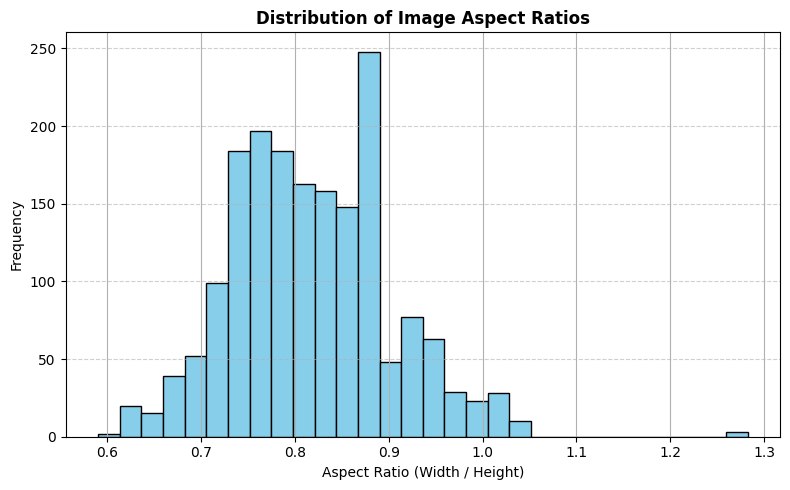

In [ ]:
# Compute aspect ratio
df['aspect'] = df['width'] / df['height']

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
df['aspect'].hist(bins=30, ax=ax, color='skyblue', edgecolor='black')

ax.set_xlabel('Aspect Ratio (Width / Height)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Image Aspect Ratios', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()


## Resolution Heatmap

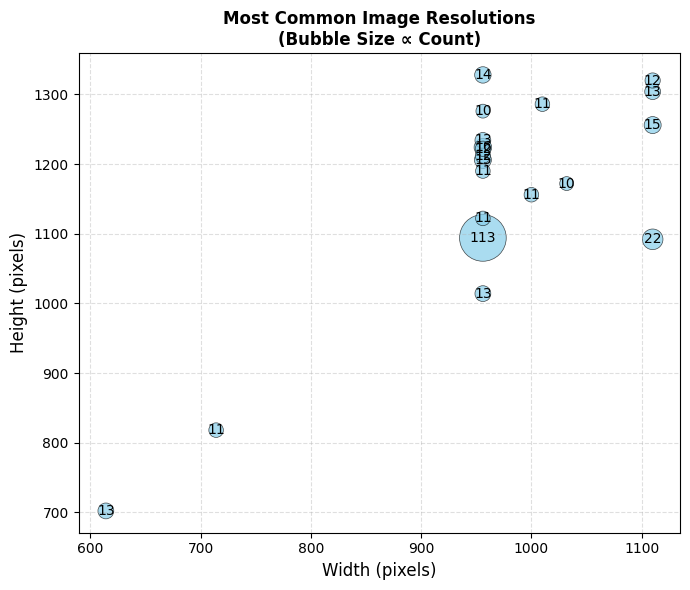

In [ ]:
# Group by width and height
wh_counts = df.groupby(['width', 'height']).size().reset_index(name='n')
top_pairs = wh_counts.sort_values('n', ascending=False).head(20)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    top_pairs['width'], top_pairs['height'],
    s=top_pairs['n'] * 10,
    alpha=0.7,
    color='skyblue',
    edgecolors='black',
    linewidth=0.5
)

# Annotate bubbles
for _, r in top_pairs.iterrows():
    ax.text(r['width'], r['height'], str(r['n']),
            ha='center', va='center',   color='black')

# Labels and styling
ax.set_xlabel('Width (pixels)', fontsize=12)
ax.set_ylabel('Height (pixels)', fontsize=12)
ax.set_title('Most Common Image Resolutions\n(Bubble Size ∝ Count)', weight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()


## Random Sample Grid

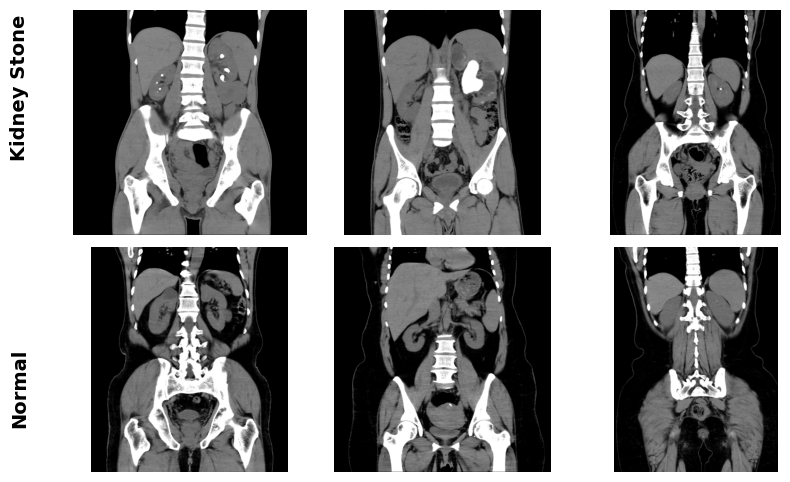

In [ ]:

# Mapping class labels to display labels
label_map = {'stone': 'Kidney Stone', 'normal': 'Normal'}

def plot_sample_grid(df, classes=['stone', 'normal'], n_cols=3):
    n_rows = len(classes)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))

    for row_idx, label in enumerate(classes):
        subset = df.query('label == @label')
        paths = random.sample(list(subset['path']), k=min(n_cols, len(subset)))
        for col_idx, path in enumerate(paths):
            ax = axes[row_idx, col_idx]
            img = Image.open(path)
            ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
            ax.axis('off')

    # Add vertical row labels
    for i, label in enumerate(classes):
        fig.text(
            0.015, 1 - (i + 0.5) / n_rows,  # fine-tuned x-position
            label_map[label],
            va='center', ha='center',
            fontsize=14, fontweight='bold',
            rotation='vertical'
        )

    # Tight layout with minimal padding
    plt.subplots_adjust(left=0.07, wspace=0.05, hspace=0.05)
    plt.show()

# Example usage
plot_sample_grid(df, classes=['stone', 'normal'], n_cols=3)


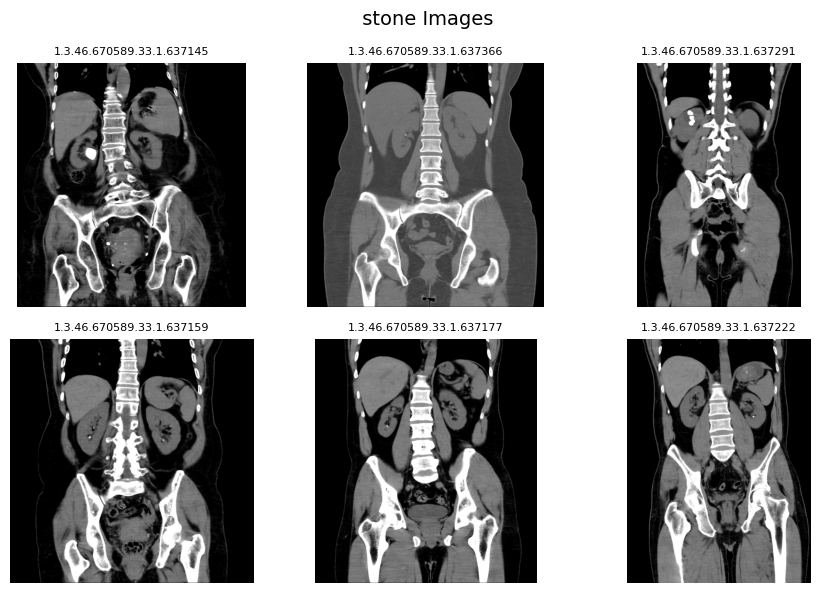

In [ ]:
def plot_samples(label, n=9):
    paths = random.sample(list(df.query('label==@label')['path']), k=n)
    rows, cols = 2, 3
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    axes = axes.flatten()
    for ax, p in itertools.zip_longest(axes, paths):
        if p is None:
            ax.axis('off'); continue
        img = Image.open(p)
        ax.imshow(img, cmap='gray' if img.mode=='L' else None)
        ax.set_title(Path(p).name[:25], fontsize=8)
        ax.axis('off')
    fig.suptitle(f' {label} Images', fontsize=14)
    plt.tight_layout()

plot_samples('stone', 6)



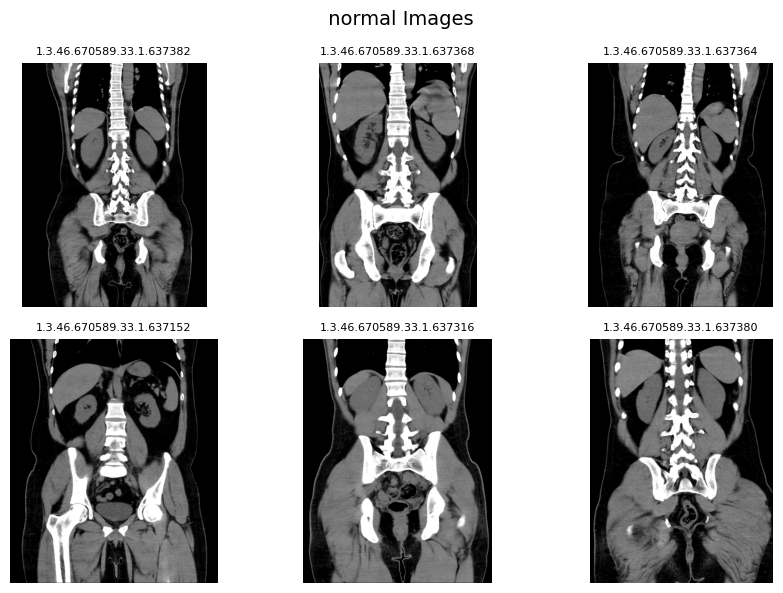

In [ ]:
plot_samples('normal', 6)

#Data Preprocessing

## Set Params

In [ ]:
IMG_SIZE   = 224
BATCH      = 32
SEED       = 42
TEST_SPLIT = 0.20
VAL_SPLIT  = 0.10
AUTOTUNE   = tf.data.AUTOTUNE

## Collect image paths & labels

In [ ]:
def list_files(folder):
    return [p for p in folder.rglob('*') if p.suffix.lower() in
            ('.jpg','.jpeg','.png','.bmp','.tif','.tiff')]

stone_files  = list_files(STONE_DIR)
normal_files = list_files(NORMAL_DIR)

files   = stone_files + normal_files
labels  = [1]*len(stone_files) + [0]*len(normal_files)   # 1 = stone, 0 = normal

df = pd.DataFrame({'path': files, 'label': labels})
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Total images: {len(df):,}  (stone {df.label.sum():,} | normal {len(df)-df.label.sum():,})")


Total images: 1,790  (stone 781 | normal 1,009)


## Data Split to Train, test, and val

In [ ]:
trainval_df, test_df = train_test_split(
    df, test_size=TEST_SPLIT, stratify=df['label'], random_state=SEED)

val_rel = VAL_SPLIT / (1 - TEST_SPLIT)
train_df, val_df = train_test_split(
    trainval_df, test_size=val_rel, stratify=trainval_df['label'], random_state=SEED)

for name, part in [('Train',train_df), ('Val',val_df), ('Test',test_df)]:
    pos = part['label'].sum()
    neg = len(part)-pos
    print(f"{name:5s}: {len(part):5d}  (stone {pos:4d} | normal {neg:4d})")


Train:  1253  (stone  547 | normal  706)
Val  :   179  (stone   78 | normal  101)
Test :   358  (stone  156 | normal  202)


## Edge Enhancement


 - The images are decoded and resized to a uniform size of 224×224, which is a common input size for the models.

- An emboss filter is applied to point out/highlight edges, highlighting important features like kidney stones. This is an edge-focused preprocessing technique.

In [ ]:
EMBOSS_K = tf.constant([[ -2., -1.,  0.],
                        [ -1.,  1.,  1.],
                        [  0.,  1.,  2. ]], dtype=tf.float32)
EMBOSS_K = EMBOSS_K[:, :, tf.newaxis, tf.newaxis]

def decode_resize_emboss(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)

    gray = tf.image.rgb_to_grayscale(img)
    filt = tf.nn.conv2d(gray[tf.newaxis], EMBOSS_K, strides=1, padding='SAME')[0]
    img  = tf.repeat(filt, 3, axis=-1)

    img  = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return img, label

## Data augmentation


- Data augmentation is applied only to the training dataset, which includes random horizontal flipping, rotations, zooming, height and width shifts, translations, and contrast adjustments.

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.3),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.Resizing(IMG_SIZE, IMG_SIZE)])

## Dataset builder

In [ ]:
def make_dataset(df, training):
    paths  = df['path'].astype(str).values
    labels = df['label'].astype(np.int32).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(decode_resize_emboss, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)

    ds = ds.map(lambda x, y: ((x * 2.) - 1., y), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df,   training=False)
test_ds  = make_dataset(test_df,  training=False)

## Augmentation check

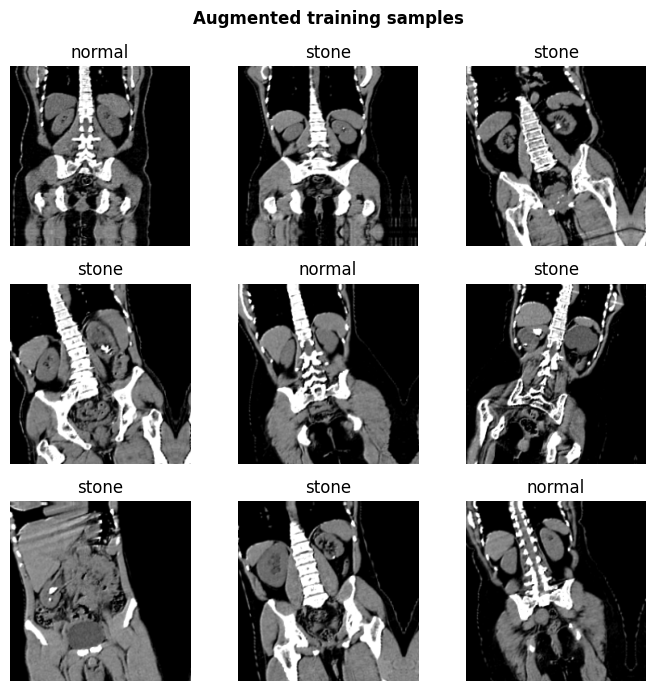

In [ ]:
def show_augmented_batch(dataset, n=9):
    imgs, lbls = next(iter(dataset))
    plt.figure(figsize=(7,7))
    for i in range(n):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow((imgs[i] + 1) / 2)
        ax.set_title('stone' if lbls[i] == 1 else 'normal')
        ax.axis('off')
    plt.suptitle('Augmented training samples',fontweight='bold')
    plt.tight_layout()

show_augmented_batch(train_ds)

# Xception Model

In [ ]:
NUM_CLASSES = 2
EPOCHS = 100

base_model = keras.applications.Xception(
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    pooling='avg')

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=True)
x       = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,865,578 (79.60 MB)

 Trainable params: 20,811,050 (79.39 MB)

 Non-trainable params: 54,528 (213.00 KB)

## Model training

In [ ]:
ckpt_path = f'model_xception_{int(time.time())}.keras'
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.25, patience=3, verbose=1)]

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 888ms/step - accuracy: 0.6358 - loss: 0.6225
Epoch 1: val_loss improved from inf to 4.57182, saving model to model_xception_1746211825.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.6379 - loss: 0.6206 - val_accuracy: 0.7877 - val_loss: 4.5718 - learning_rate: 0.0010
Epoch 2/100
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.8739 - loss: 0.3530
Epoch 2: val_loss did not improve from 4.57182
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 272ms/step - accuracy: 0.8745 - loss: 0.3518 - val_accuracy: 0.4358 - val_loss: 42.9148 - learning_rate: 0.0010
Epoch 3/100
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9243 - loss: 0.2296
Epoch 3: val_loss did not improve from 4.57182
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 273ms/step - accuracy: 0.9239 - loss: 0.2304 - val_accuracy: 0.4804 - val_loss: 7.2837 - learning_rate: 0.0010
Epoch 4/100
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.9199 - loss: 0.2563
Epoch 4: val_loss did not improve fro

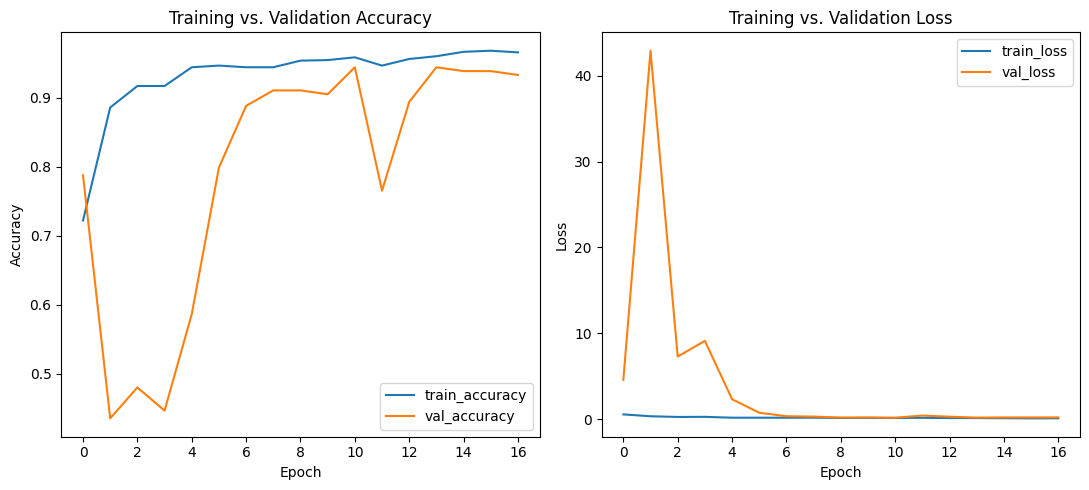

In [ ]:
def plot_history_side_by_side(hist):
    metrics = ['accuracy', 'loss']
    titles = ['Accuracy', 'Loss']

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    for i, m in enumerate(metrics):
        axes[i].plot(hist.history[m], label=f'train_{m}')
        axes[i].plot(hist.history[f'val_{m}'], label=f'val_{m}')
        axes[i].set_title(f'Training vs. Validation {titles[i]}')
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel(titles[i])
        axes[i].legend()

    plt.tight_layout()
    plt.show()

plot_history_side_by_side(history)


## Evaluating model performance using the unseen test set

In [ ]:
y_true = []
y_pred = []
for imgs, lbls in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_true.extend(lbls.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("Xception classification report:\n",
      classification_report(y_true, y_pred, target_names=['Normal','Kidney Stone']))

Xception classification report:
               precision    recall  f1-score   support

      normal       0.95      0.93      0.94       202
Kidney Stone       0.91      0.94      0.92       156

    accuracy                           0.93       358
   macro avg       0.93      0.93      0.93       358
weighted avg       0.93      0.93      0.93       358



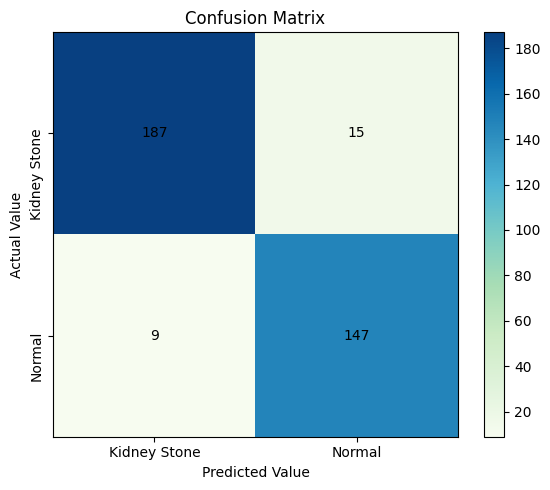

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
classes = ['Kidney Stone', 'Normal']

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='GnBu')
cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=10)

# Axis settings
ax.set(
    xticks=np.arange(len(classes)),
    yticks=np.arange(len(classes)),
    xticklabels=classes,
    xlabel='Predicted Value',
    ylabel='Actual Value',
    title='Confusion Matrix',
)

# Set vertical Y-axis labels
ax.set_yticklabels(classes, rotation=90)

# Annotate with raw counts only
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]}", ha='center', va='center')

plt.tight_layout()
plt.show()


In [ ]:
# Extract values
TN, FP, FN, TP = cm.ravel()

# Compute metrics
sensitivity = TP / (TP + FN)   # Recall
specificity = TN / (TN + FP)

print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")


Sensitivity: 0.9423
Specificity: 0.9257


# MobileNetV2 Model

In [ ]:
NUM_CLASSES = 2
MB_EPOCHS = 100

base_model = keras.applications.MobileNetV2(
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    pooling='avg')


In [ ]:
inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=True)
x       = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
mobilenet_model = keras.Model(inputs, outputs)

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

mobilenet_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,226,434 (8.49 MB)

 Non-trainable params: 34,112 (133.25 KB)

## Model training

In [ ]:
ckpt_path_mb = f'mobilenetv2_{int(time.time())}.keras'

mb_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(ckpt_path_mb, monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.25, patience=3, verbose=1)]

mb_history = mobilenet_model.fit( train_ds, validation_data=val_ds, epochs=MB_EPOCHS, callbacks=mb_callbacks)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.5772 - loss: 0.8002
Epoch 1: val_loss improved from inf to 1.68692, saving model to mobilenetv2_1746213296.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.5796 - loss: 0.7969 - val_accuracy: 0.6425 - val_loss: 1.6869 - learning_rate: 0.0010
Epoch 2/100
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.8441 - loss: 0.3922
Epoch 2: val_loss did not improve from 1.68692
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 268ms/step - accuracy: 0.8445 - loss: 0.3905 - val_accuracy: 0.6313 - val_loss: 4.0867 - learning_rate: 0.0010
Epoch 3/100
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.8798 - loss: 0.3050
Epoch 3: val_loss improved from 1.68692 to 1.58269, saving model to mobilenetv2_1746213296.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 286ms/step - accuracy: 0.8799 - loss: 0.3050 - val_accuracy: 0.7933 - val_loss: 1.5827 - learning_rate: 0.0010
Epoch 4/100
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9036 - loss

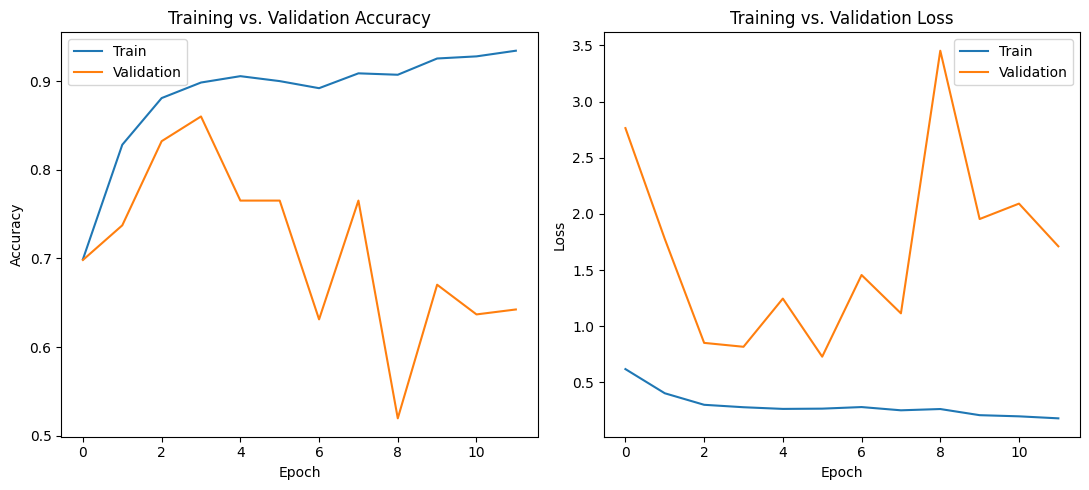

In [ ]:
def plot_history(hist):
    metrics = ['accuracy', 'loss']
    titles = ['Accuracy', 'Loss']

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))  # 1 row, 2 columns

    for i, m in enumerate(metrics):
        axes[i].plot(hist.history[m], label='Train')
        axes[i].plot(hist.history[f'val_{m}'], label='Validation')
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel(titles[i])
        axes[i].set_title(f'Training vs. Validation {titles[i]}')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

# Usage
plot_history(mb_history)

## Evaluating model performance using the unseen test set

In [ ]:
y_true, y_pred = [], []
for imgs, lbls in test_ds:
    preds = mobilenet_model.predict(imgs, verbose=0)
    y_true.extend(lbls.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("MobileNet Classification Report:\n",
      classification_report(y_true, y_pred, target_names=['normal','Kidney Stone']))

MobileNet Classification Report:
               precision    recall  f1-score   support

      normal       0.82      0.72      0.77       202
Kidney Stone       0.69      0.80      0.74       156

    accuracy                           0.76       358
   macro avg       0.76      0.76      0.76       358
weighted avg       0.77      0.76      0.76       358



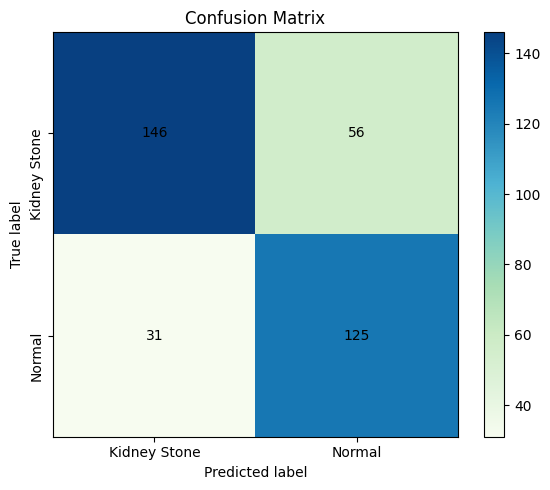

In [ ]:
# Compute confusion matrix
cm_mb = confusion_matrix(y_true, y_pred)
classes = ['Kidney Stone', 'Normal']

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_mb, interpolation='nearest', cmap='GnBu')
cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=10)

# Set axis ticks and labels
ax.set(
    xticks=np.arange(len(classes)),
    yticks=np.arange(len(classes)),
    xticklabels=classes,
    xlabel='Predicted label',
    ylabel='True label',
    title='Confusion Matrix'
)

# Set Y-axis labels to vertical
ax.set_yticklabels(classes, rotation=90)

# Add text annotations (counts only)
for i in range(cm_mb.shape[0]):
    for j in range(cm_mb.shape[1]):
        ax.text(j, i, f"{cm_mb[i, j]}", ha='center', va='center')

plt.tight_layout()
plt.grid(False)
plt.show()


In [ ]:
# Compute confusion matrix
cm_mb = confusion_matrix(y_true, y_pred)


TN, FP, FN, TP = cm_mb.ravel()

# Compute metrics
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Sensitivity: 0.8013
Specificity: 0.7228


# InceptionResNetV2


In [ ]:
NUM_CLASSES = 2
INCEP_EPOCHS = 100

base_model_incep = keras.applications.InceptionResNetV2(
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    pooling='avg')

In [ ]:
inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model_incep(inputs, training=True)
x       = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

inceptionresnetv2_model = keras.Model(inputs, outputs)

inceptionresnetv2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),    # LR 0.001
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

inceptionresnetv2_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_resnet_v2             │ (None, 1536)           │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         3,074 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,339,810 (207.29 MB)

 Trainable params: 54,279,266 (207.06 MB)

 Non-trainable params: 60,544 (236.50 KB)

## Model training

In [ ]:
ckpt_path_incep = f'inceptionresnetv2_{int(time.time())}.keras'

incep_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(ckpt_path_incep, monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.25, patience=3, verbose=1)]


incep_history = inceptionresnetv2_model.fit( train_ds, validation_data=val_ds, epochs=INCEP_EPOCHS,callbacks=incep_callbacks)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6581 - loss: 0.7474   
Epoch 1: val_loss improved from inf to 5.69151, saving model to inceptionresnetv2_1746213966.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.6596 - loss: 0.7437 - val_accuracy: 0.4246 - val_loss: 5.6915 - learning_rate: 0.0010
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.8830 - loss: 0.3013
Epoch 2: val_loss improved from 5.69151 to 0.57139, saving model to inceptionresnetv2_1746213966.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 398ms/step - accuracy: 0.8832 - loss: 0.3009 - val_accuracy: 0.6816 - val_loss: 0.5714 - learning_rate: 0.0010
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9178 - loss: 0.2356
Epoch 3: val_loss did not improve from 0.57139
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 280ms/step - accuracy: 0.9180 - loss: 0.2352 - val_accuracy: 0.4525 - val_loss: 7.8193 - learning_rate: 0.0010
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0

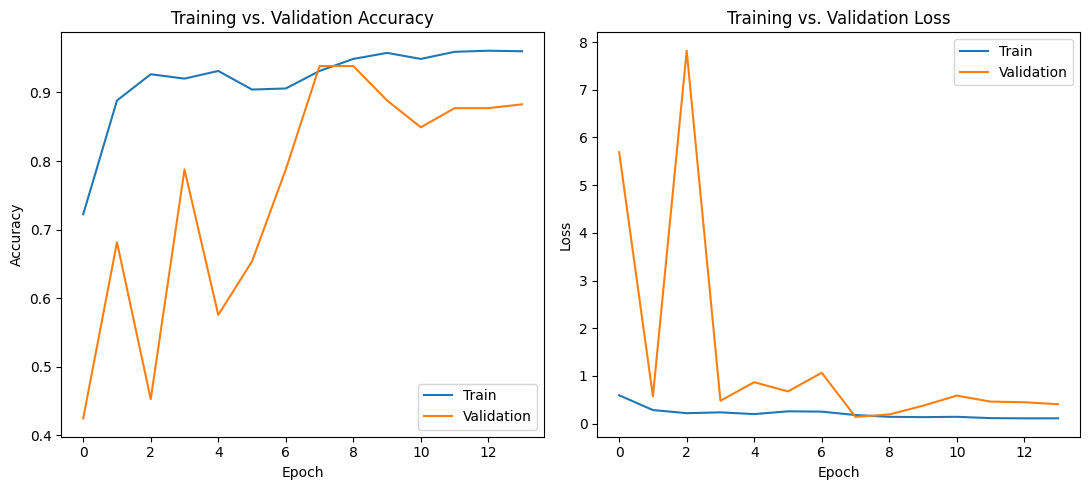

In [ ]:
def plot_history(hist, title_prefix):
    metrics = ['accuracy', 'loss']
    titles = ['Accuracy', 'Loss']

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    for i, metric in enumerate(metrics):
        axes[i].plot(hist.history[metric], label='Train')
        axes[i].plot(hist.history[f'val_{metric}'], label='Validation')
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel(titles[i])
        axes[i].set_title(f'Training vs. Validation {titles[i]}')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

# Example usage
plot_history(incep_history, 'InceptionResNetV2')

## Evaluating model performance using the unseen test set

In [ ]:
y_true, y_pred = [], []
for imgs, lbls in test_ds:
    preds = inceptionresnetv2_model.predict(imgs, verbose=0)
    y_true.extend(lbls.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("Inception ResNetV2 classification report:\n",
      classification_report(y_true, y_pred, target_names=['Normal','Kidney Stone']))

Inception ResNetV2 classification report:
               precision    recall  f1-score   support

      Normal       0.97      0.96      0.97       202
Kidney Stone       0.95      0.96      0.96       156

    accuracy                           0.96       358
   macro avg       0.96      0.96      0.96       358
weighted avg       0.96      0.96      0.96       358



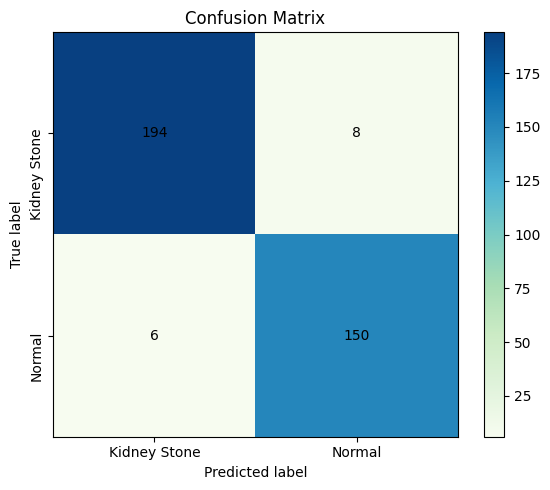

In [ ]:
# Compute confusion matrix
cm_incep = confusion_matrix(y_true, y_pred)
classes = ['Kidney Stone', 'Normal']

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_incep, interpolation='nearest', cmap='GnBu')
cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=10)

# Set axis ticks and labels
ax.set(
    xticks=np.arange(len(classes)),
    yticks=np.arange(len(classes)),
    xticklabels=classes,
    xlabel='Predicted label',
    ylabel='True label',
    title='Confusion Matrix'
)

# Set vertical Y-axis labels
ax.set_yticklabels(classes, rotation=90)

# Annotate cells with raw counts only
for i in range(cm_incep.shape[0]):
    for j in range(cm_incep.shape[1]):
        ax.text(j, i, f"{cm_incep[i, j]}", ha='center', va='center' )

plt.tight_layout()
plt.grid(False)
plt.show()

In [ ]:
TN, FP, FN, TP = cm_incep.ravel()

# Calculate sensitivity and specificity
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")


Sensitivity: 0.9615
Specificity: 0.9604


#ResNet50 Model


In [ ]:
NUM_CLASSES = 2
RESNET_EPOCHS = 100

base_model_resnet = keras.applications.ResNet50(
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    pooling='avg')

In [ ]:
inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model_resnet(inputs, training=True)
x       = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

resnet50_model = keras.Model(inputs, outputs)

resnet50_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

resnet50_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 23,538,690 (89.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

## Model training

In [ ]:
ckpt_path_resnet = f'resnet50_{int(time.time())}.keras'

resnet_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(ckpt_path_resnet, monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.25, patience=3, verbose=1)]

resnet_history = resnet50_model.fit( train_ds, validation_data=val_ds, epochs=RESNET_EPOCHS, callbacks=resnet_callbacks)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.5878 - loss: 1.0919
Epoch 1: val_loss improved from inf to 172.16310, saving model to resnet50_1746216806.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 89s 949ms/step - accuracy: 0.5892 - loss: 1.0866 - val_accuracy: 0.5642 - val_loss: 172.1631 - learning_rate: 0.0010
Epoch 2/100
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.7903 - loss: 0.4600
Epoch 2: val_loss improved from 172.16310 to 1.78989, saving model to resnet50_1746216806.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 320ms/step - accuracy: 0.7922 - loss: 0.4567 - val_accuracy: 0.5642 - val_loss: 1.7899 - learning_rate: 0.0010
Epoch 3/100
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.7677 - loss: 0.5153
Epoch 3: val_loss improved from 1.78989 to 0.70307, saving model to resnet50_1746216806.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 367ms/step - accuracy: 0.7685 - loss: 0.5140 - val_accuracy: 0.4525 - val_loss: 0.7031 - learning_rate: 0.0010
Epoch 4/100
39/40 ━━━━━━━━━━━

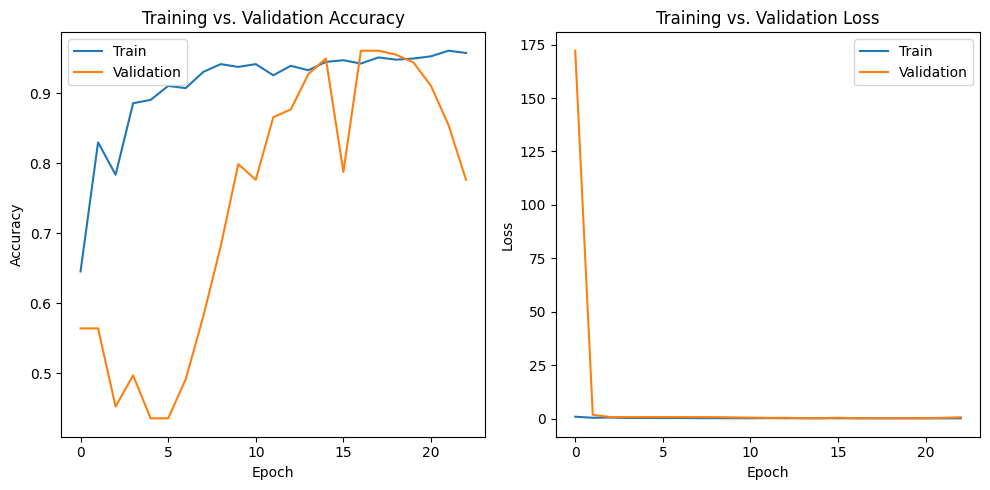

In [ ]:
def plot_history(hist, title_prefix):
    metrics = ['accuracy', 'loss']
    titles = ['Accuracy', 'Loss']

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    for i, metric in enumerate(metrics):
        axes[i].plot(hist.history[metric], label='Train')
        axes[i].plot(hist.history[f'val_{metric}'], label='Validation')
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel(titles[i])
        axes[i].set_title(f'Training vs. Validation {titles[i]}')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

# Example usage
plot_history(resnet_history, 'ResNet50')

## Evaluating model performance using the unseen test set

In [ ]:
y_true, y_pred = [], []
for imgs, lbls in test_ds:
    preds = resnet50_model.predict(imgs, verbose=0)
    y_true.extend(lbls.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("ResNet50 classification report:\n",
      classification_report(y_true, y_pred, target_names=['Normal','Kidney Stone']))

ResNet50 classification report:
               precision    recall  f1-score   support

      Normal       0.96      0.99      0.97       202
Kidney Stone       0.99      0.94      0.96       156

    accuracy                           0.97       358
   macro avg       0.97      0.97      0.97       358
weighted avg       0.97      0.97      0.97       358



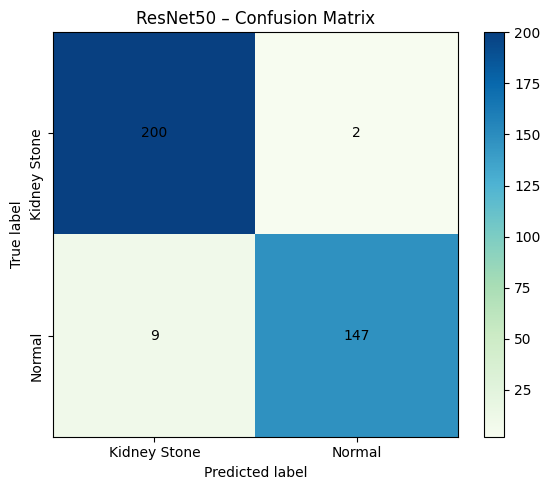

In [ ]:

# Compute confusion matrix
cm_resnet = confusion_matrix(y_true, y_pred)
classes = ['Kidney Stone', 'Normal']

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_resnet, interpolation='nearest', cmap='GnBu')
cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=10)

# Set axis ticks and labels
ax.set(
    xticks=np.arange(len(classes)),
    yticks=np.arange(len(classes)),
    xticklabels=classes,
    xlabel='Predicted label',
    ylabel='True label',
    title='ResNet50 – Confusion Matrix'
)

# Set Y-axis labels to vertical
ax.set_yticklabels(classes, rotation=90)

# Annotate with raw counts only
for i in range(cm_resnet.shape[0]):
    for j in range(cm_resnet.shape[1]):
        ax.text(j, i, f"{cm_resnet[i, j]}", ha='center', va='center')

plt.tight_layout()
plt.grid(False)
plt.show()

In [ ]:
TN, FP, FN, TP = cm_resnet.ravel()

# Calculate sensitivity and specificity
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print("ResNet50 – Evaluation Metrics")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

ResNet50 – Evaluation Metrics
Sensitivity: 0.9423
Specificity: 0.9901


#Compare between models

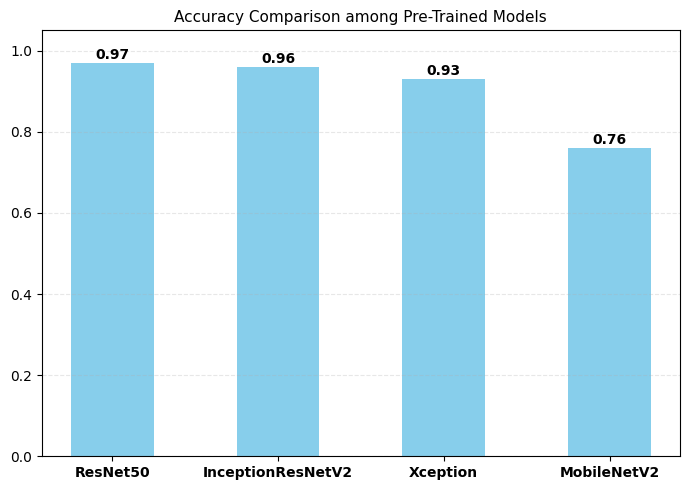

In [ ]:
# Model names and accuracies
models = ['ResNet50', 'InceptionResNetV2', 'Xception', 'MobileNetV2']
accuracies = [0.97, 0.96, 0.93, 0.76]

# Plot
plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color='skyblue',width=0.5)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f'{height:.2f}', ha='center', fontweight='bold')

# Style
plt.ylim(0, 1.05)
plt.title('Accuracy Comparison among Pre-Trained Models', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.3)

# Make x-axis labels bold
plt.xticks(fontweight='bold')

plt.tight_layout()
plt.show()